In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
print("GeoPandas:", gpd.__version__)
print("Pandas:", pd.__version__)

GeoPandas: 1.1.4
Pandas: 3.0.5


In [3]:
from pathlib import Path

DATA_PATH = Path("../data/raw/vg250/vg250_ebenen_0101/DE_VG250.gpkg")

print(DATA_PATH)
print(DATA_PATH.exists())

..\data\raw\vg250\vg250_ebenen_0101\DE_VG250.gpkg
True


In [4]:
import pyogrio

layers = pyogrio.list_layers(DATA_PATH)
layers

array([['vg250_vwg', 'MultiPolygon'],
       ['vg250_sta', 'MultiPolygon'],
       ['vg250_rbz', 'MultiPolygon'],
       ['vg250_pk', 'Point'],
       ['vg250_li', 'LineString'],
       ['vg250_lan', 'MultiPolygon'],
       ['vg250_krs', 'MultiPolygon'],
       ['vg250_gem', 'MultiPolygon'],
       ['v_vg250_gem', 'MultiPolygon'],
       ['v_vg250_vwg', 'MultiPolygon'],
       ['v_vg250_krs', 'MultiPolygon'],
       ['v_vg250_rbz', 'MultiPolygon'],
       ['v_vg250_lan', 'MultiPolygon'],
       ['v_vg250_sta', 'MultiPolygon'],
       ['v_vg250_li', 'LineString'],
       ['v_vg250_pk', 'Point'],
       ['v_vg250_f', 'MultiPolygon'],
       ['v_vz250_gem', 'MultiPolygon'],
       ['vg_lkz', None],
       ['vgtb_vz_gem', None],
       ['vgtb_rgs_vg', None],
       ['vgtb_rgs_otl', None],
       ['vgtb_azb_vg', None],
       ['vg_werte', None],
       ['vg_ibz', None],
       ['vg_daten', None],
       ['v_at_vg', None],
       ['v_vgtb_att_vg', None],
       ['v_vgtb_azb_vg', None],
     

In [5]:
layers.shape

(44, 2)

In [16]:
spatial_layers = layers[layers[:,1] != None]

In [17]:
spatial_layers

array([['vg250_vwg', 'MultiPolygon'],
       ['vg250_sta', 'MultiPolygon'],
       ['vg250_rbz', 'MultiPolygon'],
       ['vg250_pk', 'Point'],
       ['vg250_li', 'LineString'],
       ['vg250_lan', 'MultiPolygon'],
       ['vg250_krs', 'MultiPolygon'],
       ['vg250_gem', 'MultiPolygon'],
       ['v_vg250_gem', 'MultiPolygon'],
       ['v_vg250_vwg', 'MultiPolygon'],
       ['v_vg250_krs', 'MultiPolygon'],
       ['v_vg250_rbz', 'MultiPolygon'],
       ['v_vg250_lan', 'MultiPolygon'],
       ['v_vg250_sta', 'MultiPolygon'],
       ['v_vg250_li', 'LineString'],
       ['v_vg250_pk', 'Point'],
       ['v_vg250_f', 'MultiPolygon'],
       ['v_vz250_gem', 'MultiPolygon']], dtype=object)

In [6]:
states = gpd.read_file(
    DATA_PATH,
    layer="vg250_lan"
)

states.head()

,OBJID,BEGINN,ADE,GF,BSG,LKZ,ARS,AGS,SDV_ARS,GEN,...,SN_V1,SN_V2,SN_G,FK_S3,NUTS,ARS_0,AGS_0,WSK,DLM_ID,geometry
0,DEBKGVG200000CJN,2025-04-12,2,4,1,SH,01,01,010020000000,Schleswig-Holstein,...,00,00,000,0,DEF,010000000000,01000000,2012-02-01,DEBKGDL200000029,"MULTIPOLYGON (((546232.578 5934903.089, 546341..."
1,DEBKGVG200000CJO,2025-01-04,2,4,1,HH,02,02,020000000000,Hamburg,...,00,00,000,0,DE6,020000000000,02000000,1974-01-01,DEBKGDL20000E6GD,"MULTIPOLYGON (((548446.373 5934566.984, 548491..."
2,DEBKGVG200000CJP,2026-06-11,2,4,1,NI,03,03,032410001001,Niedersachsen,...,00,00,000,0,DE9,030000000000,03000000,2015-01-01,DEBKGDL20000E6EW,"MULTIPOLYGON (((551261.85 5933835.255, 551252...."
3,DEBKGVG200000CJQ,2025-04-12,2,4,1,HB,04,04,040110000000,Bremen,...,00,00,000,0,DE5,040000000000,04000000,2010-01-01,DEBKGDL20000E0SF,"MULTIPOLYGON (((474373.709 5894257.104, 474294..."
4,DEBKGVG200000CJR,2026-06-11,2,4,1,NW,05,05,051110000000,Nordrhein-Westfalen,...,00,00,000,0,DEA,050000000000,05000000,2009-11-01,DEBKGDL20000E6GR,"MULTIPOLYGON (((301890.303 5600399.203, 301901..."


In [18]:
print("Shape: ", states.shape)
print("Columns: ", states.columns.tolist())
print("CRS", states.crs)

Shape:  (34, 27)
Columns:  ['OBJID', 'BEGINN', 'ADE', 'GF', 'BSG', 'LKZ', 'ARS', 'AGS', 'SDV_ARS', 'GEN', 'BEZ', 'IBZ', 'BEM', 'NBD', 'SN_L', 'SN_R', 'SN_K', 'SN_V1', 'SN_V2', 'SN_G', 'FK_S3', 'NUTS', 'ARS_0', 'AGS_0', 'WSK', 'DLM_ID', 'geometry']
CRS EPSG:25832


There is an anomaly here, because we expected 16 states. However, there are 34 rows so it is crucial to investigate what those rows mean rather than deleting duplicates directly.

In [21]:
states[["GEN", "BEZ", "GF", "BSG", "SN_L"]]

,GEN,BEZ,GF,BSG,SN_L
0,Schleswig-Holstein,Land,4,1,01
1,Hamburg,Freie und Hansestadt,4,1,02
2,Niedersachsen,Land,4,1,03
3,Bremen,Freie Hansestadt,4,1,04
4,Nordrhein-Westfalen,Land,4,1,05
5,Hessen,Land,4,1,06
6,Rheinland-Pfalz,Land,4,1,07
7,Baden-Württemberg,Land,4,1,08
8,Bayern,Freistaat,4,1,09
9,Saarland,Land,4,1,10


In [22]:
states["GEN"].value_counts()

GEN
Niedersachsen                   6
Schleswig-Holstein              5
Hamburg                         3
Baden-Württemberg               3
Mecklenburg-Vorpommern          3
Bremen                          2
Nordrhein-Westfalen             1
Hessen                          1
Rheinland-Pfalz                 1
Bayern                          1
Saarland                        1
Berlin                          1
Brandenburg                     1
Sachsen                         1
Sachsen-Anhalt                  1
Thüringen                       1
Baden-Württemberg (Bodensee)    1
Bayern (Bodensee)               1
Name: count, dtype: int64

In [23]:
states["GF"].value_counts()

GF
4    16
2     8
1     8
3     2
Name: count, dtype: int64

Important to note: GF = 4 has 16 values in the dataset, which matches 16 states in Germany.

In [24]:
states.groupby("GEN").size().sort_values(ascending=False)

GEN
Niedersachsen                   6
Schleswig-Holstein              5
Mecklenburg-Vorpommern          3
Baden-Württemberg               3
Hamburg                         3
Bremen                          2
Baden-Württemberg (Bodensee)    1
Berlin                          1
Brandenburg                     1
Bayern                          1
Hessen                          1
Bayern (Bodensee)               1
Rheinland-Pfalz                 1
Nordrhein-Westfalen             1
Saarland                        1
Sachsen                         1
Sachsen-Anhalt                  1
Thüringen                       1
dtype: int64

In [25]:
states[
    states["GEN"].str.contains("Baden-Württemberg", na=False)
][["GEN", "GF", "BSG", "BEZ", "SN_L", "geometry"]]

,GEN,GF,BSG,BEZ,SN_L,geometry
7,Baden-Württemberg,4,1,Land,08,"MULTIPOLYGON (((477035.141 5496309.3, 476890.5..."
24,Baden-Württemberg,2,1,Land,08,"MULTIPOLYGON (((508108.48 5281339.714, 508180...."
30,Baden-Württemberg,1,1,Land,08,"MULTIPOLYGON (((499412.983 5287739.797, 499482..."
32,Baden-Württemberg (Bodensee),1,9,Land,08,"MULTIPOLYGON (((503362.578 5295901.508, 503397..."


In [28]:
bw_all = states[
    states["GEN"].str.contains("Baden-Württemberg", na=False)
].copy()

In [29]:
bw_all[["GEN", "GF", "BSG"]]

,GEN,GF,BSG
7,Baden-Württemberg,4,1
24,Baden-Württemberg,2,1
30,Baden-Württemberg,1,1
32,Baden-Württemberg (Bodensee),1,9


As per the official documentation, GF (Geofaktor) = 4 can be used to isolate land. Which is why we will filter of the basis of GF.

In [35]:
land_states = states[
    states["GF"] == 4
].copy()

In [36]:
land_states.shape

(16, 27)

In [37]:
land_states["GEN"].sort_values().tolist()

['Baden-Württemberg',
 'Bayern',
 'Berlin',
 'Brandenburg',
 'Bremen',
 'Hamburg',
 'Hessen',
 'Mecklenburg-Vorpommern',
 'Niedersachsen',
 'Nordrhein-Westfalen',
 'Rheinland-Pfalz',
 'Saarland',
 'Sachsen',
 'Sachsen-Anhalt',
 'Schleswig-Holstein',
 'Thüringen']

In [38]:
bw = land_states[
    land_states["GEN"] == "Baden-Württemberg"
].copy()

In [39]:
bw.shape

(1, 27)

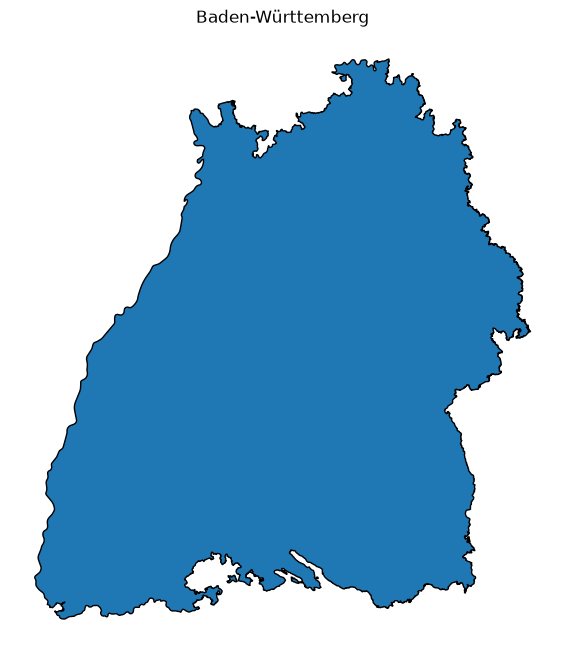

In [40]:
fig, ax = plt.subplots(figsize=(8, 8))

bw.plot(
    ax=ax,
    edgecolor="black"
)

ax.set_title("Baden-Württemberg")
ax.axis("off")

plt.show()

In [42]:
bw_area_km2 = bw.geometry.area.iloc[0] / 1_000_000

print(f"Area: {bw_area_km2:,.2f} km²")

Area: 35,722.69 km²


Now, to analyse the Co-ordinate Reference System

In [44]:
bw.crs

<Projected CRS: EPSG:25832>
Name: ETRS89 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°E and 12°E: Austria; Denmark - onshore and offshore; Germany - onshore and offshore; Italy - onshore and offshore; Norway including Svalbard - onshore and offshore; Spain - offshore.
- bounds: (6.0, 36.53, 12.01, 84.01)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

<Projected CRS: EPSG:25832> --> This indicates that the distance in measured in METRES. GeoPandas provides functions to convert between different CRS types.

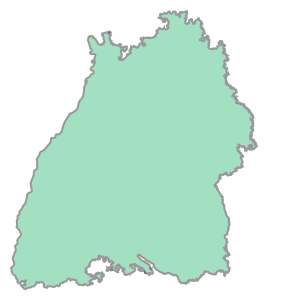

In [53]:
bw.geometry.iloc[0]

In [54]:
bw.total_bounds

array([ 388342.98617618, 5265154.34498366,  610082.00959236,
       5515648.53868784])

In [55]:
bw_wgs84 = bw.to_crs(epsg=4326) #changing the CRS to WGS84 (EPSG:4326)

bw_wgs84.total_bounds

array([ 7.51187183, 47.53236022, 10.49574878, 49.79147765])